# 03 Evaluation

This notebook selects decoding settings on validation data, then runs a held-out test evaluation with the trained heatmap model and plots qualitative results.


# Setup


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass

from pathlib import Path

if Path('/content/drive/MyDrive').exists():
    PROJECT_DIR = Path('/content/drive/MyDrive/Multi-Person-Detection')
elif Path.cwd().name == 'notebooks':
    PROJECT_DIR = Path.cwd().parent
else:
    PROJECT_DIR = Path.cwd()

RAW_DATA_DIR = PROJECT_DIR / 'data' / 'raw'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
MODEL_DIR = PROJECT_DIR / 'models'
EVALUATION_DIR = PROJECT_DIR / 'evaluation_results'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

print('Project directory:', PROJECT_DIR)
print('Processed data directory:', PROCESSED_DIR)
print('Model directory:', MODEL_DIR)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/Multi-Person-Detection
Processed data directory: /content/drive/MyDrive/Multi-Person-Detection/data/processed
Model directory: /content/drive/MyDrive/Multi-Person-Detection/models


# Import Libraries


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.ndimage import maximum_filter
from scipy.optimize import linear_sum_assignment
from tensorflow import keras
from IPython.display import display


# Configuration


In [3]:
config_path = PROCESSED_DIR / 'preprocessing_config.json'
if not config_path.exists():
    raise FileNotFoundError(
        f'Missing preprocessing configuration: {config_path}. '
        'Run notebook 01 before evaluation.'
    )

with open(config_path, 'r', encoding='utf-8') as f:
    preprocessing_config = json.load(f)

ROOM_X = float(preprocessing_config['room_x'])
ROOM_Y = float(preprocessing_config['room_y'])
MAX_PERSONS = int(preprocessing_config['max_people'])

MATCH_THRESHOLD = 1.0
HEATMAP_THRESHOLD = 0.25
NMS_SIZE = 3
BATCH_SIZE = 64

print('Loaded preprocessing configuration:', config_path)


Loaded preprocessing configuration: /content/drive/MyDrive/Multi-Person-Detection/data/processed/preprocessing_config.json


# Load Validation Data and Model


In [4]:
X_validation = np.load(PROCESSED_DIR / 'X_validation.npy')
y_coordinates_validation = np.load(PROCESSED_DIR / 'y_coordinates_validation.npy')
y_mask_validation = np.load(PROCESSED_DIR / 'y_mask_validation.npy')

model_path = MODEL_DIR / 'best_heatmap_model.keras'
if not model_path.exists():
    model_path = MODEL_DIR / 'final_heatmap_model_best_weights.keras'

model = keras.models.load_model(model_path, compile=False)

print('Loaded model:', model_path)
print('X_validation:', X_validation.shape)
print('y_coordinates_validation:', y_coordinates_validation.shape)
print('y_mask_validation:', y_mask_validation.shape)


Loaded model: /content/drive/MyDrive/Multi-Person-Detection/models/best_heatmap_model.keras
X_validation: (1872, 16, 55, 24)
y_coordinates_validation: (1872, 4, 2)
y_mask_validation: (1872, 4)


# Validation Predictions


In [5]:
y_pred_validation = model.predict(X_validation, batch_size=BATCH_SIZE)
np.save(EVALUATION_DIR / 'y_pred_validation.npy', y_pred_validation)

print('y_pred_validation shape:', y_pred_validation.shape)


30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 264ms/step
y_pred_validation shape: (1872, 24, 16, 1)


# Metrics


In [6]:
# ============================================================
# Official-style evaluation constants
# ============================================================

MATCH_THRESHOLD = 1.0   # metres
ROOM_X_MAX = ROOM_X
ROOM_Y_MAX = ROOM_Y


# ============================================================
# 1. Convert predicted heatmap to predicted localizations
# ============================================================

def heatmap_to_localizations(
    heatmap,
    threshold=HEATMAP_THRESHOLD,
    nms_size=NMS_SIZE,
    max_persons=MAX_PERSONS,
    room_x=ROOM_X_MAX,
    room_y=ROOM_Y_MAX
):
    """
    heatmap: (H, W) or (H, W, 1)

    Returns:
        localizations: list of [x, y]
        scores: list of confidence scores
    """

    if heatmap.ndim == 3:
        heatmap = heatmap[:, :, 0]

    H, W = heatmap.shape

    # Local maxima detection
    local_max = maximum_filter(heatmap, size=nms_size) == heatmap

    # Thresholded peaks
    detected = local_max & (heatmap >= threshold)

    rows, cols = np.where(detected)

    if len(rows) == 0:
        return [], []

    scores = heatmap[rows, cols]

    # Sort by score, descending
    order = np.argsort(scores)[::-1]
    rows = rows[order]
    cols = cols[order]
    scores = scores[order]

    # Keep at most 4 people
    rows = rows[:max_persons]
    cols = cols[:max_persons]
    scores = scores[:max_persons]

    localizations = []

    for r, c in zip(rows, cols):
        x = (c / (W - 1)) * room_x
        y = (r / (H - 1)) * room_y

        # Clamp to official room bounds
        x = float(np.clip(x, 0.0, room_x))
        y = float(np.clip(y, 0.0, room_y))

        localizations.append([x, y])

    return localizations, scores.tolist()


# ============================================================
# 2. Convert GT xy/mask to official-style localizations

def gt_to_localizations(xy, mask):
    """
    xy:   (4, 2)
    mask: (4,)

    Returns:
        list of [x, y]
    """

    localizations = []

    for i in range(len(mask)):
        if mask[i] < 0.5:
            continue

        x, y = xy[i]

        x = float(np.clip(x, 0.0, ROOM_X_MAX))
        y = float(np.clip(y, 0.0, ROOM_Y_MAX))

        localizations.append([x, y])

    return localizations


# ============================================================
# 3. Hungarian matching exactly like official evaluator
# ============================================================

def cost_matrix(gt, pred):
    gt_arr = np.array(gt, dtype=np.float64)
    pred_arr = np.array(pred, dtype=np.float64)

    diff = gt_arr[:, None, :] - pred_arr[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=-1))


def match_hungarian(gt, pred, threshold=1.0):
    """
    Returns:
        tp_distances, n_fn, n_fp
    """

    n_gt = len(gt)
    n_pred = len(pred)

    if n_gt == 0 and n_pred == 0:
        return [], 0, 0

    if n_gt == 0:
        return [], 0, n_pred

    if n_pred == 0:
        return [], n_gt, 0

    cost = cost_matrix(gt, pred)
    row_i, col_i = linear_sum_assignment(cost)

    matched_gt = set()
    matched_pred = set()
    distances = []

    for r, c in zip(row_i, col_i):
        d = float(cost[r, c])

        if d <= threshold:
            distances.append(d)
            matched_gt.add(r)
            matched_pred.add(c)

    n_fn = n_gt - len(matched_gt)
    n_fp = n_pred - len(matched_pred)

    return distances, n_fn, n_fp


# ============================================================
# 4. Full global F1 evaluation
# ============================================================

def evaluate_official_style_from_heatmaps(
    y_pred_heat,
    y_coordinates,
    y_mask,
    threshold=HEATMAP_THRESHOLD,
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS,
    verbose=True
):
    """
    Computes official-style global F1:

    For each frame:
        predicted positions matched to GT using Hungarian algorithm.
        Match is TP only if distance <= 1.0 m.
        Unmatched predictions = FP.
        Unmatched GT = FN.

    Globally:
        Precision = TP / (TP + FP)
        Recall    = TP / (TP + FN)
        F1        = 2PR / (P + R)
    """

    total_tp = 0
    total_fp = 0
    total_fn = 0

    all_tp_distances = []

    count_abs_errors = []
    count_exact = 0

    gt_records = {}
    pred_records = {}

    for frame_id in range(len(y_pred_heat)):

        gt_locs = gt_to_localizations(
            y_coordinates[frame_id],
            y_mask[frame_id]
        )

        pred_locs, scores = heatmap_to_localizations(
            y_pred_heat[frame_id],
            threshold=threshold,
            nms_size=nms_size,
            max_persons=max_persons,
            room_x=ROOM_X_MAX,
            room_y=ROOM_Y_MAX
        )

        gt_records[frame_id] = gt_locs
        pred_records[frame_id] = pred_locs

        dists, n_fn, n_fp = match_hungarian(
            gt_locs,
            pred_locs,
            threshold=match_threshold
        )

        total_tp += len(dists)
        total_fp += n_fp
        total_fn += n_fn

        all_tp_distances.extend(dists)

        count_abs_errors.append(abs(len(pred_locs) - len(gt_locs)))

        if len(pred_locs) == len(gt_locs):
            count_exact += 1

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    if len(all_tp_distances) > 0:
        d = np.array(all_tp_distances, dtype=np.float64)
        rmse = float(np.sqrt(np.mean(d ** 2)))
        mae = float(np.mean(d))
        median = float(np.median(d))
        p90 = float(np.percentile(d, 90))
        n_matches = len(d)
    else:
        rmse = None
        mae = None
        median = None
        p90 = None
        n_matches = 0

    count_mae = float(np.mean(count_abs_errors)) if len(count_abs_errors) > 0 else 0.0
    count_acc = count_exact / len(y_pred_heat) if len(y_pred_heat) > 0 else 0.0

    results = {
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "rmse": rmse,
        "mae": mae,
        "median": median,
        "p90": p90,
        "matched_pairs": n_matches,
        "count_mae": count_mae,
        "count_accuracy": count_acc,
        "threshold": threshold,
        "nms_size": nms_size,
        "match_threshold": match_threshold,
        "gt_records": gt_records,
        "pred_records": pred_records
    }

    if verbose:
        print("=" * 62)
        print("  DETECTION SCORE - OFFICIAL-STYLE F1")
        print("=" * 62)
        print(f"  Heatmap threshold  : {threshold}")
        print(f"  NMS size           : {nms_size}")
        print(f"  Matching threshold : {match_threshold} m")
        print(f"  Frames evaluated   : {len(y_pred_heat)}")
        print(f"  TP / FP / FN       : {total_tp} / {total_fp} / {total_fn}")
        print(f"  Precision          : {precision:.4f}")
        print(f"  Recall             : {recall:.4f}")
        print(f"  F1 Score           : {f1:.4f}")
        print()

        print("-" * 62)
        print("LOCALISATION ERROR  (matched pairs only)")
        print("-" * 62)

        if n_matches > 0:
            print(f"  Matched pairs      : {n_matches}")
            print(f"  RMSE               : {rmse:.4f} m")
            print(f"  MAE                : {mae:.4f} m")
            print(f"  Median error       : {median:.4f} m")
            print(f"  P90 error          : {p90:.4f} m")
        else:
            print("  No matches found - cannot compute localisation error.")

        print()

        print("-" * 62)
        print("PERSON COUNT")
        print("-" * 62)
        print(f"  Count MAE          : {count_mae:.4f} persons / frame")
        print(f"  Count accuracy     : {count_acc:.2%}  ({count_exact} / {len(y_pred_heat)} frames)")
        print("=" * 62)

        print("JSON_RESULT:", json.dumps({
            "f1": round(f1, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "rmse": round(rmse, 4) if rmse is not None else None
        }))

    return results


# ============================================================
# 5. Run evaluation
# ============================================================

results = evaluate_official_style_from_heatmaps(
    y_pred_validation,
    y_coordinates_validation,
    y_mask_validation,
    threshold=HEATMAP_THRESHOLD,
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS,
    verbose=True
)


  DETECTION SCORE - OFFICIAL-STYLE F1
  Heatmap threshold  : 0.25
  NMS size           : 3
  Matching threshold : 1.0 m
  Frames evaluated   : 1872
  TP / FP / FN       : 1854 / 500 / 2826
  Precision          : 0.7876
  Recall             : 0.3962
  F1 Score           : 0.5272

--------------------------------------------------------------
LOCALISATION ERROR  (matched pairs only)
--------------------------------------------------------------
  Matched pairs      : 1854
  RMSE               : 0.5293 m
  MAE                : 0.4685 m
  Median error       : 0.4318 m
  P90 error          : 0.8341 m

--------------------------------------------------------------
PERSON COUNT
--------------------------------------------------------------
  Count MAE          : 1.2543 persons / frame
  Count accuracy     : 6.57%  (123 / 1872 frames)
JSON_RESULT: {"f1": 0.5272, "precision": 0.7876, "recall": 0.3962, "rmse": 0.5293}


# Validation Threshold Sweep

Choose the heatmap threshold on validation data only. The held-out test set remains untouched until the final evaluation.


In [7]:
def sweep_thresholds_official_style(
    y_pred_heat,
    y_coordinates,
    y_mask,
    thresholds=np.arange(0.05, 0.81, 0.05),
    nms_size=5,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS
):
    sweep = []

    for th in thresholds:
        res = evaluate_official_style_from_heatmaps(
            y_pred_heat,
            y_coordinates,
            y_mask,
            threshold=float(th),
            nms_size=nms_size,
            match_threshold=match_threshold,
            max_persons=max_persons,
            verbose=False
        )

        sweep.append(res)

        print(
            f"threshold={th:.2f} | "
            f"F1={res['f1']:.4f} | "
            f"P={res['precision']:.4f} | "
            f"R={res['recall']:.4f} | "
            f"TP={res['tp']} FP={res['fp']} FN={res['fn']} | "
            f"Count MAE={res['count_mae']:.3f}"
        )

    best = max(sweep, key=lambda r: r["f1"])

    print("\n===== BEST THRESHOLD =====")
    print(f"Best threshold : {best['threshold']}")
    print(f"Best F1        : {best['f1']:.4f}")
    print(f"Precision      : {best['precision']:.4f}")
    print(f"Recall         : {best['recall']:.4f}")
    print(f"TP / FP / FN   : {best['tp']} / {best['fp']} / {best['fn']}")

    return sweep, best


sweep_results, best_result = sweep_thresholds_official_style(
    y_pred_validation,
    y_coordinates_validation,
    y_mask_validation,
    thresholds=np.arange(0.05, 0.99, 0.05),
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS
)


threshold=0.05 | F1=0.5553 | P=0.6522 | R=0.4835 | TP=2263 FP=1207 FN=2417 | Count MAE=0.807
threshold=0.10 | F1=0.5592 | P=0.7082 | R=0.4620 | TP=2162 FP=891 FN=2518 | Count MAE=0.942
threshold=0.15 | F1=0.5495 | P=0.7364 | R=0.4382 | TP=2051 FP=734 FN=2629 | Count MAE=1.053
threshold=0.20 | F1=0.5410 | P=0.7633 | R=0.4190 | TP=1961 FP=608 FN=2719 | Count MAE=1.147
threshold=0.25 | F1=0.5272 | P=0.7876 | R=0.3962 | TP=1854 FP=500 FN=2826 | Count MAE=1.254
threshold=0.30 | F1=0.5102 | P=0.8048 | R=0.3735 | TP=1748 FP=424 FN=2932 | Count MAE=1.345
threshold=0.35 | F1=0.4933 | P=0.8243 | R=0.3519 | TP=1647 FP=351 FN=3033 | Count MAE=1.435
threshold=0.40 | F1=0.4716 | P=0.8375 | R=0.3282 | TP=1536 FP=298 FN=3144 | Count MAE=1.520
threshold=0.45 | F1=0.4423 | P=0.8519 | R=0.2987 | TP=1398 FP=243 FN=3282 | Count MAE=1.623
threshold=0.50 | F1=0.4076 | P=0.8603 | R=0.2671 | TP=1250 FP=203 FN=3430 | Count MAE=1.724
threshold=0.55 | F1=0.3698 | P=0.8609 | R=0.2355 | TP=1102 FP=178 FN=3578 | Cou

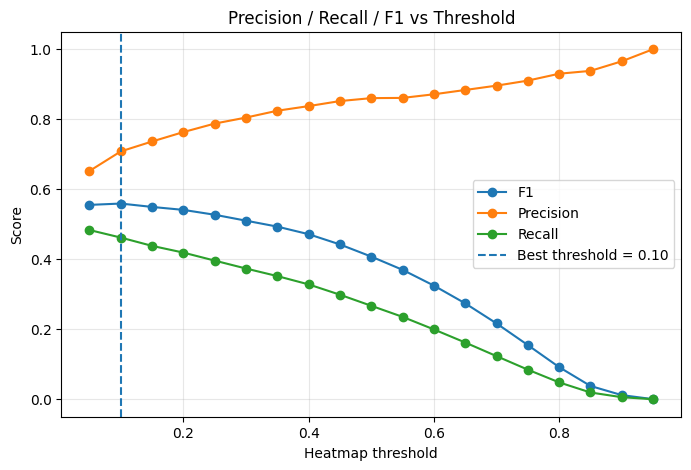

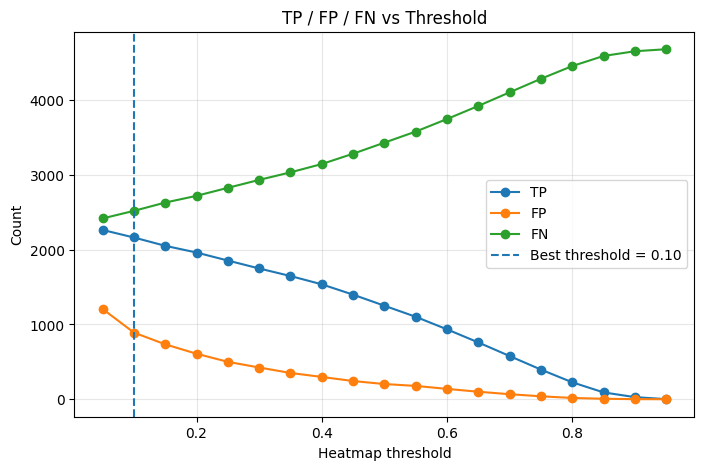

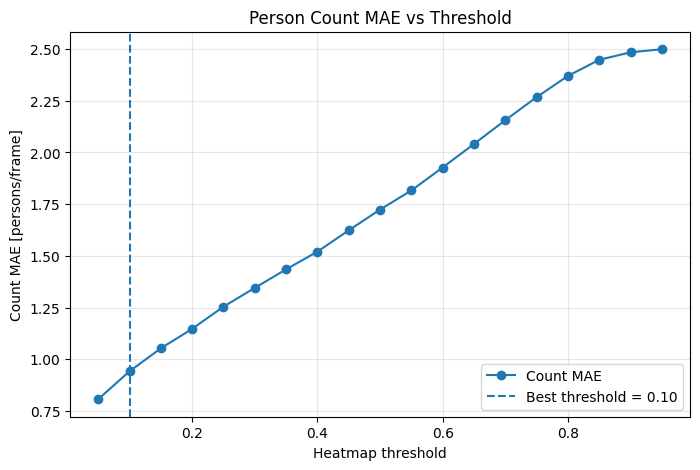

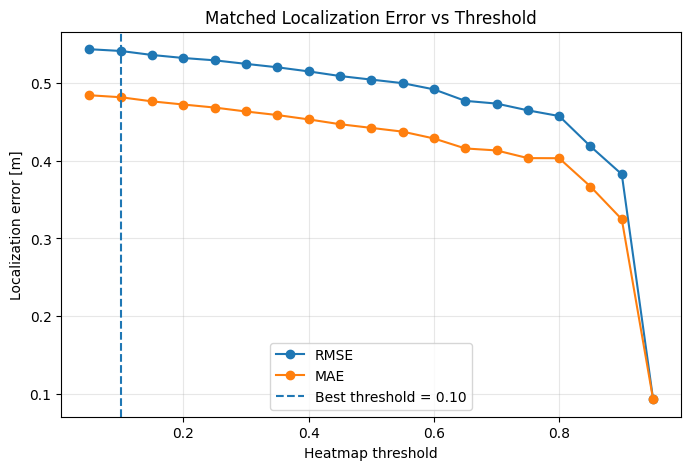

In [8]:
def plot_threshold_sweep_official_style(sweep_results, best_result=None):
    thresholds = np.array([r["threshold"] for r in sweep_results])

    f1 = np.array([r["f1"] for r in sweep_results])
    precision = np.array([r["precision"] for r in sweep_results])
    recall = np.array([r["recall"] for r in sweep_results])

    tp = np.array([r["tp"] for r in sweep_results])
    fp = np.array([r["fp"] for r in sweep_results])
    fn = np.array([r["fn"] for r in sweep_results])

    count_mae = np.array([r["count_mae"] for r in sweep_results])

    rmse = np.array([
        np.nan if r["rmse"] is None else r["rmse"]
        for r in sweep_results
    ])

    mae = np.array([
        np.nan if r["mae"] is None else r["mae"]
        for r in sweep_results
    ])

    # -------------------------
    # Plot 1: Precision / Recall / F1
    # -------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1, marker="o", label="F1")
    plt.plot(thresholds, precision, marker="o", label="Precision")
    plt.plot(thresholds, recall, marker="o", label="Recall")

    if best_result is not None:
        best_th = best_result["threshold"]
        plt.axvline(best_th, linestyle="--", label=f"Best threshold = {best_th:.2f}")

    plt.xlabel("Heatmap threshold")
    plt.ylabel("Score")
    plt.title("Precision / Recall / F1 vs Threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # -------------------------
    # Plot 2: TP / FP / FN
    # -------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, tp, marker="o", label="TP")
    plt.plot(thresholds, fp, marker="o", label="FP")
    plt.plot(thresholds, fn, marker="o", label="FN")

    if best_result is not None:
        best_th = best_result["threshold"]
        plt.axvline(best_th, linestyle="--", label=f"Best threshold = {best_th:.2f}")

    plt.xlabel("Heatmap threshold")
    plt.ylabel("Count")
    plt.title("TP / FP / FN vs Threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # -------------------------
    # Plot 3: Count MAE
    # -------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, count_mae, marker="o", label="Count MAE")

    if best_result is not None:
        best_th = best_result["threshold"]
        plt.axvline(best_th, linestyle="--", label=f"Best threshold = {best_th:.2f}")

    plt.xlabel("Heatmap threshold")
    plt.ylabel("Count MAE [persons/frame]")
    plt.title("Person Count MAE vs Threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # -------------------------
    # Plot 4: Localization error on matched pairs
    # -------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, rmse, marker="o", label="RMSE")
    plt.plot(thresholds, mae, marker="o", label="MAE")

    if best_result is not None:
        best_th = best_result["threshold"]
        plt.axvline(best_th, linestyle="--", label=f"Best threshold = {best_th:.2f}")

    plt.xlabel("Heatmap threshold")
    plt.ylabel("Localization error [m]")
    plt.title("Matched Localization Error vs Threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


plot_threshold_sweep_official_style(
    sweep_results,
    best_result
)


# Evaluate Test Set at Best Validation Threshold

Run this held-out test evaluation only after the threshold and decoding settings are fixed.


In [9]:
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_coordinates_test = np.load(PROCESSED_DIR / 'y_coordinates_test.npy')
y_mask_test = np.load(PROCESSED_DIR / 'y_mask_test.npy')

y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE)
np.save(EVALUATION_DIR / 'y_pred_test.npy', y_pred_test)

print('X_test:', X_test.shape)
print('y_coordinates_test:', y_coordinates_test.shape)
print('y_mask_test:', y_mask_test.shape)
print('y_pred_test:', y_pred_test.shape)

final_results = evaluate_official_style_from_heatmaps(
    y_pred_test,
    y_coordinates_test,
    y_mask_test,
    threshold=best_result["threshold"],
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS,
    verbose=True
)


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step
X_test: (2340, 16, 55, 24)
y_coordinates_test: (2340, 4, 2)
y_mask_test: (2340, 4)
y_pred_test: (2340, 24, 16, 1)
  DETECTION SCORE - OFFICIAL-STYLE F1
  Heatmap threshold  : 0.1
  NMS size           : 3
  Matching threshold : 1.0 m
  Frames evaluated   : 2340
  TP / FP / FN       : 2453 / 847 / 2227
  Precision          : 0.7433
  Recall             : 0.5241
  F1 Score           : 0.6148

--------------------------------------------------------------
LOCALISATION ERROR  (matched pairs only)
--------------------------------------------------------------
  Matched pairs      : 2453
  RMSE               : 0.5077 m
  MAE                : 0.4451 m
  Median error       : 0.4046 m
  P90 error          : 0.8169 m

--------------------------------------------------------------
PERSON COUNT
--------------------------------------------------------------
  Count MAE          : 0.7444 persons / frame
  Count accuracy     : 55.21%  (1292 / 2340 frames)
JSON_

# Test Metrics by True Person Count

The global F1 score can hide systematic errors. Group the held-out test frames by their true number of people to expose empty-room false positives, crowded-scene misses, and localization errors even when the predicted count is correct.


In [10]:
def evaluate_by_true_person_count(
    y_pred_heat,
    y_coordinates,
    y_mask,
    threshold,
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS,
):
    """Summarize held-out metrics after grouping frames by true people count."""
    true_people_counts = np.sum(y_mask >= 0.5, axis=1).astype(np.int32)
    rows = []

    for true_people_count in range(max_persons + 1):
        group_indices = np.flatnonzero(true_people_counts == true_people_count)

        if len(group_indices) == 0:
            rows.append({
                'true_people_count': true_people_count,
                'frames': 0,
                'mean_predicted_count': None,
                'count_accuracy': None,
                'underprediction_rate': None,
                'overprediction_rate': None,
                'tp': 0,
                'fp': 0,
                'fn': 0,
                'fp_per_frame': None,
                'fn_per_frame': None,
                'precision': None,
                'recall': None,
                'f1': None,
                'matched_localization_mae_m': None,
                'correct_count_assignment_mae_m': None,
                'correct_count_all_localized_rate': None,
            })
            continue

        group_results = evaluate_official_style_from_heatmaps(
            y_pred_heat[group_indices],
            y_coordinates[group_indices],
            y_mask[group_indices],
            threshold=threshold,
            nms_size=nms_size,
            match_threshold=match_threshold,
            max_persons=max_persons,
            verbose=False,
        )

        predicted_counts = []
        correct_count_assignment_distances = []
        correct_count_frames = 0
        correct_count_all_localized_frames = 0

        for frame_index in group_indices:
            gt_locs = gt_to_localizations(
                y_coordinates[frame_index],
                y_mask[frame_index],
            )
            pred_locs, _ = heatmap_to_localizations(
                y_pred_heat[frame_index],
                threshold=threshold,
                nms_size=nms_size,
                max_persons=max_persons,
                room_x=ROOM_X_MAX,
                room_y=ROOM_Y_MAX,
            )

            predicted_counts.append(len(pred_locs))

            if len(pred_locs) != len(gt_locs):
                continue

            correct_count_frames += 1

            if len(gt_locs) == 0:
                correct_count_all_localized_frames += 1
                continue

            distances = cost_matrix(gt_locs, pred_locs)
            gt_indices, pred_indices = linear_sum_assignment(distances)
            assignment_distances = distances[gt_indices, pred_indices]

            correct_count_assignment_distances.extend(
                assignment_distances.tolist()
            )

            if np.all(assignment_distances <= match_threshold):
                correct_count_all_localized_frames += 1

        predicted_counts = np.array(predicted_counts, dtype=np.int32)

        rows.append({
            'true_people_count': true_people_count,
            'frames': len(group_indices),
            'mean_predicted_count': float(np.mean(predicted_counts)),
            'count_accuracy': group_results['count_accuracy'],
            'underprediction_rate': float(np.mean(predicted_counts < true_people_count)),
            'overprediction_rate': float(np.mean(predicted_counts > true_people_count)),
            'tp': group_results['tp'],
            'fp': group_results['fp'],
            'fn': group_results['fn'],
            'fp_per_frame': group_results['fp'] / len(group_indices),
            'fn_per_frame': group_results['fn'] / len(group_indices),
            'precision': group_results['precision'],
            'recall': group_results['recall'],
            'f1': group_results['f1'],
            'matched_localization_mae_m': group_results['mae'],
            'correct_count_assignment_mae_m': (
                float(np.mean(correct_count_assignment_distances))
                if correct_count_assignment_distances
                else None
            ),
            'correct_count_all_localized_rate': (
                correct_count_all_localized_frames / correct_count_frames
                if correct_count_frames > 0
                else None
            ),
        })

    return pd.DataFrame(rows)


test_metrics_by_true_person_count = evaluate_by_true_person_count(
    y_pred_test,
    y_coordinates_test,
    y_mask_test,
    threshold=best_result['threshold'],
    nms_size=NMS_SIZE,
    match_threshold=MATCH_THRESHOLD,
    max_persons=MAX_PERSONS,
)
test_metrics_by_true_person_count.to_csv(
    EVALUATION_DIR / 'test_metrics_by_true_person_count.csv',
    index=False,
)
display(test_metrics_by_true_person_count)


,true_people_count,frames,mean_predicted_count,count_accuracy,underprediction_rate,overprediction_rate,tp,fp,fn,fp_per_frame,fn_per_frame,precision,recall,f1,matched_localization_mae_m,correct_count_assignment_mae_m,correct_count_all_localized_rate
0,0,468,0.000000,1.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000
1,1,468,1.014957,0.985043,0.000000,0.014957,467,8,1,0.017094,0.002137,0.983158,0.997863,0.990456,0.312849,0.314018,0.997831
2,2,468,2.138889,0.487179,0.228632,0.284188,589,412,347,0.880342,0.741453,0.588412,0.629274,0.608157,0.520365,0.931326,0.451754
3,3,468,1.175214,0.032051,0.963675,0.004274,414,136,990,0.290598,2.115385,0.752727,0.294872,0.423746,0.520009,1.165486,0.066667
4,4,468,2.722222,0.256410,0.743590,0.000000,983,291,889,0.621795,1.899573,0.771586,0.525107,0.624921,0.431212,1.008521,0.083333


# Detailed Coordinate Predictions

Inspect a reproducible sample of decoded predictions at the selected threshold. The table reports matched detections, missed people, false positives, and empty-room true negatives.


In [11]:
def show_coordinate_predictions_at_best_threshold(
    y_pred_heat,
    y_coordinates,
    y_mask,
    best_result,
    num_examples=10,
    nms_size=NMS_SIZE,
    max_persons=MAX_PERSONS,
    match_threshold=MATCH_THRESHOLD,
    random_state=42,
):
    """Build a detailed matching table for a reproducible sample of frames."""
    threshold = best_result['threshold']
    rng = np.random.default_rng(random_state)
    indices = rng.choice(
        len(y_pred_heat),
        size=min(num_examples, len(y_pred_heat)),
        replace=False,
    )

    rows = []

    for sample_idx in indices:
        gt_locs = gt_to_localizations(
            y_coordinates[sample_idx],
            y_mask[sample_idx],
        )
        pred_locs, scores = heatmap_to_localizations(
            y_pred_heat[sample_idx],
            threshold=threshold,
            nms_size=nms_size,
            max_persons=max_persons,
            room_x=ROOM_X_MAX,
            room_y=ROOM_Y_MAX,
        )

        matched_gt = set()
        matched_pred = set()

        if gt_locs and pred_locs:
            distances = cost_matrix(gt_locs, pred_locs)
            gt_indices, pred_indices = linear_sum_assignment(distances)

            for gt_idx, pred_idx in zip(gt_indices, pred_indices):
                distance = float(distances[gt_idx, pred_idx])
                if distance <= match_threshold:
                    status = 'TP'
                    matched_gt.add(int(gt_idx))
                    matched_pred.add(int(pred_idx))
                else:
                    status = 'Too far'

                rows.append({
                    'sample_idx': int(sample_idx),
                    'type': status,
                    'gt_id': int(gt_idx),
                    'pred_id': int(pred_idx),
                    'gt_x': gt_locs[gt_idx][0],
                    'gt_y': gt_locs[gt_idx][1],
                    'pred_x': pred_locs[pred_idx][0],
                    'pred_y': pred_locs[pred_idx][1],
                    'score': scores[pred_idx],
                    'distance_m': distance,
                })

        for gt_idx, gt_loc in enumerate(gt_locs):
            if gt_idx not in matched_gt:
                rows.append({
                    'sample_idx': int(sample_idx),
                    'type': 'FN',
                    'gt_id': gt_idx,
                    'pred_id': None,
                    'gt_x': gt_loc[0],
                    'gt_y': gt_loc[1],
                    'pred_x': None,
                    'pred_y': None,
                    'score': None,
                    'distance_m': None,
                })

        for pred_idx, pred_loc in enumerate(pred_locs):
            if pred_idx not in matched_pred:
                rows.append({
                    'sample_idx': int(sample_idx),
                    'type': 'FP',
                    'gt_id': None,
                    'pred_id': pred_idx,
                    'gt_x': None,
                    'gt_y': None,
                    'pred_x': pred_loc[0],
                    'pred_y': pred_loc[1],
                    'score': scores[pred_idx],
                    'distance_m': None,
                })

        if not gt_locs and not pred_locs:
            rows.append({
                'sample_idx': int(sample_idx),
                'type': 'TN_empty',
                'gt_id': None,
                'pred_id': None,
                'gt_x': None,
                'gt_y': None,
                'pred_x': None,
                'pred_y': None,
                'score': None,
                'distance_m': None,
            })

    columns = [
        'sample_idx', 'type', 'gt_id', 'pred_id',
        'gt_x', 'gt_y', 'pred_x', 'pred_y', 'score', 'distance_m',
    ]
    return pd.DataFrame(rows, columns=columns)


coordinate_prediction_examples = show_coordinate_predictions_at_best_threshold(
    y_pred_test,
    y_coordinates_test,
    y_mask_test,
    best_result,
    num_examples=10,
    nms_size=NMS_SIZE,
    max_persons=MAX_PERSONS,
    match_threshold=MATCH_THRESHOLD,
    random_state=42,
)
coordinate_prediction_examples.to_csv(
    EVALUATION_DIR / 'coordinate_prediction_examples.csv',
    index=False,
)
display(coordinate_prediction_examples)


,sample_idx,type,gt_id,pred_id,gt_x,gt_y,pred_x,pred_y,score,distance_m
0,200,Too far,0.0,1.0,3.315088,1.237264,2.88,2.504348,0.191353,1.339702
1,200,Too far,1.0,0.0,3.810283,4.434902,3.20,3.130435,0.192137,1.440166
2,200,FN,0.0,NaN,3.315088,1.237264,NaN,NaN,NaN,NaN
3,200,FN,1.0,NaN,3.810283,4.434902,NaN,NaN,NaN,NaN
4,200,FP,NaN,0.0,NaN,NaN,3.20,3.130435,0.192137,NaN
5,200,FP,NaN,1.0,NaN,NaN,2.88,2.504348,0.191353,NaN
6,1804,TP,0.0,0.0,2.079884,4.504196,1.92,4.382609,0.860774,0.200864
7,208,TP,0.0,0.0,1.067984,1.213548,1.60,1.878261,0.586695,0.851401
8,208,Too far,1.0,1.0,1.105682,4.144348,1.60,5.947826,0.166716,1.869996
9,208,FN,1.0,NaN,1.105682,4.144348,NaN,NaN,NaN,NaN


# Qualitative Results


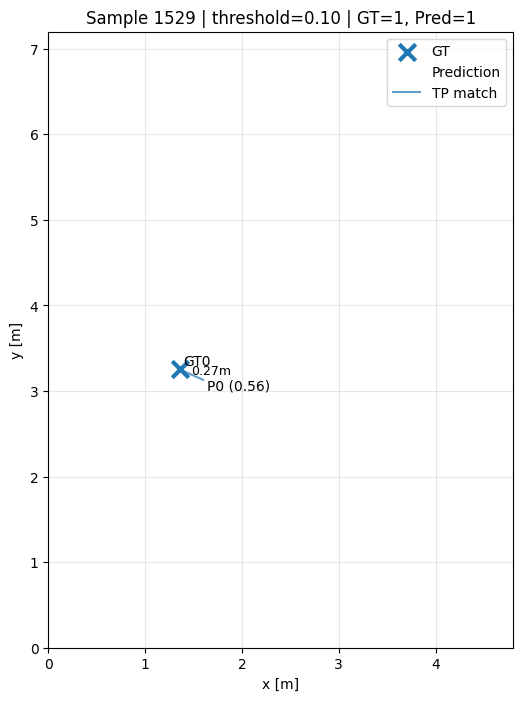

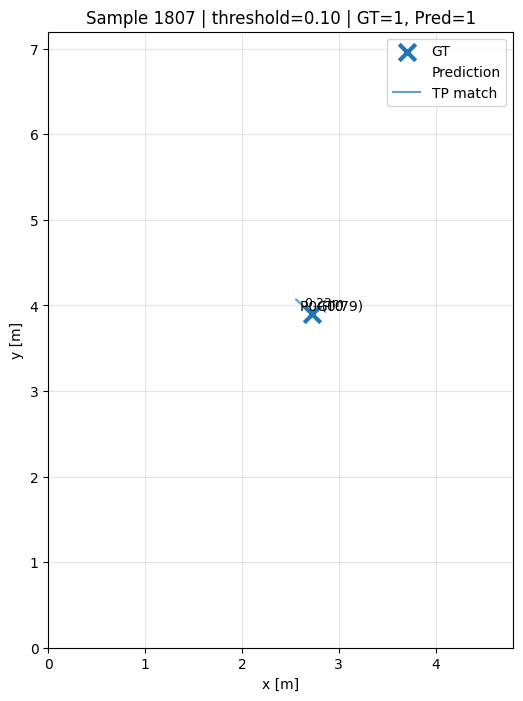

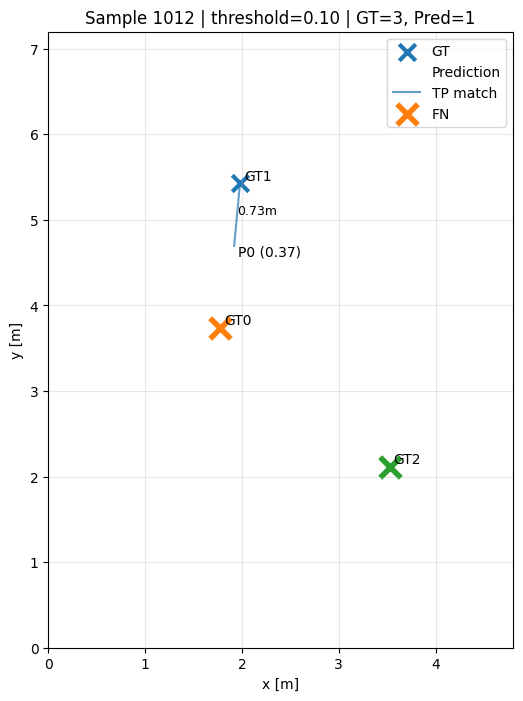

/tmp/ipykernel_2191/2848538964.py:150: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


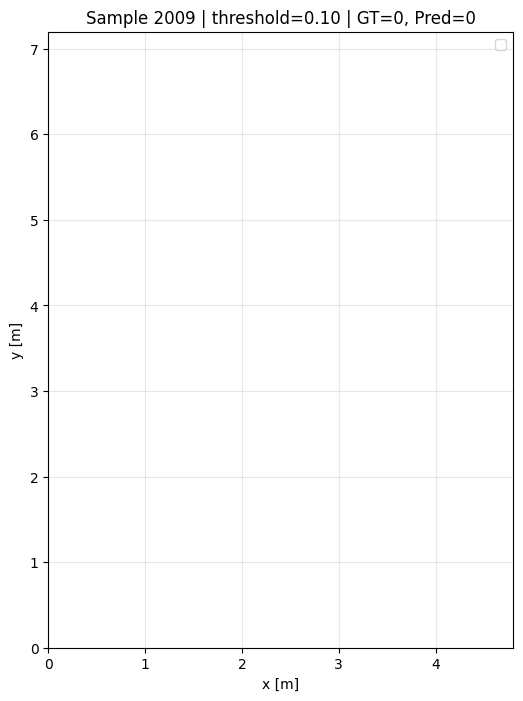

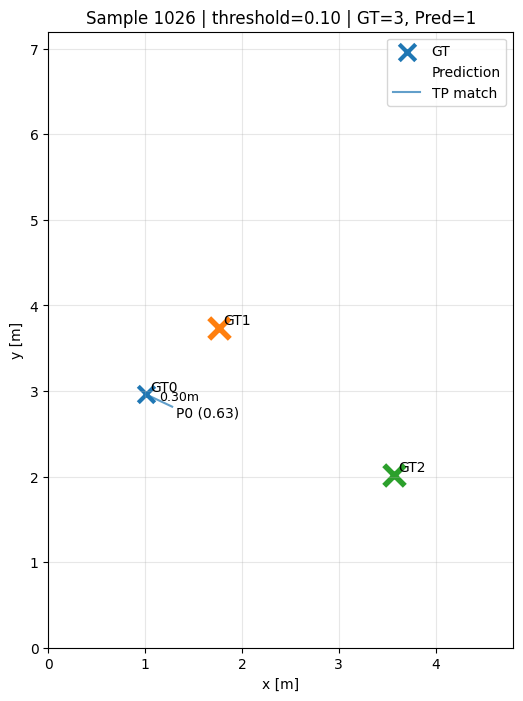

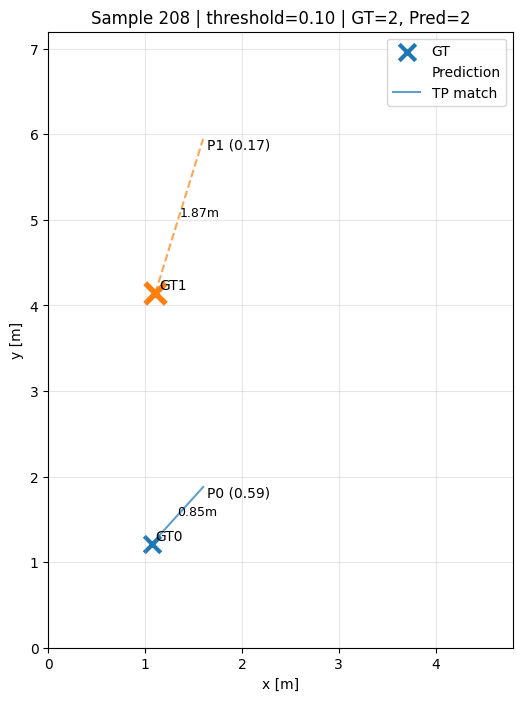

In [12]:
def plot_pred_vs_gt_coordinates(
    y_pred_heat,
    y_coordinates,
    y_mask,
    best_result,
    indices=None,
    num_examples=6,
    nms_size=NMS_SIZE,
    max_persons=MAX_PERSONS,
    match_threshold=MATCH_THRESHOLD,
    room_x=ROOM_X_MAX,
    room_y=ROOM_Y_MAX,
    random_state=42
):
    threshold = best_result["threshold"]

    if indices is None:
        rng = np.random.default_rng(random_state)
        indices = rng.choice(
            len(y_pred_heat),
            size=min(num_examples, len(y_pred_heat)),
            replace=False
        )

    for idx in indices:
        # Predicted coordinates from heatmap
        pred_locs, scores = heatmap_to_localizations(
            y_pred_heat[idx],
            threshold=threshold,
            nms_size=nms_size,
            max_persons=max_persons,
            room_x=room_x,
            room_y=room_y
        )

        # GT coordinates
        gt_locs = gt_to_localizations(
            y_coordinates[idx],
            y_mask[idx]
        )

        pred_locs = np.array(pred_locs, dtype=np.float32)
        gt_locs = np.array(gt_locs, dtype=np.float32)
        scores = np.array(scores, dtype=np.float32)

        plt.figure(figsize=(6, 8))

        # Room boundary
        plt.xlim(0, room_x)
        plt.ylim(0, room_y)
        plt.xlabel("x [m]")
        plt.ylabel("y [m]")
        plt.title(
            f"Sample {idx} | threshold={threshold:.2f} | "
            f"GT={len(gt_locs)}, Pred={len(pred_locs)}"
        )
        plt.grid(True, alpha=0.3)

        # Plot GT points
        if len(gt_locs) > 0:
            plt.scatter(
                gt_locs[:, 0],
                gt_locs[:, 1],
                marker="x",
                s=140,
                linewidths=3,
                label="GT"
            )

            for i, (x, y) in enumerate(gt_locs):
                plt.text(x + 0.04, y + 0.04, f"GT{i}", fontsize=10)

        # Plot predicted points
        if len(pred_locs) > 0:
            plt.scatter(
                pred_locs[:, 0],
                pred_locs[:, 1],
                marker="o",
                s=120,
                facecolors="none",
                linewidths=2,
                label="Prediction"
            )

            for i, (x, y) in enumerate(pred_locs):
                score_text = f"{scores[i]:.2f}" if len(scores) > i else ""
                plt.text(x + 0.04, y - 0.12, f"P{i} ({score_text})", fontsize=10)

        # Hungarian matching lines
        if len(gt_locs) > 0 and len(pred_locs) > 0:
            dist_matrix = np.linalg.norm(
                gt_locs[:, None, :] - pred_locs[None, :, :],
                axis=2
            )

            gt_idx, pred_idx = linear_sum_assignment(dist_matrix)

            matched_gt = set()
            matched_pred = set()

            for g, p in zip(gt_idx, pred_idx):
                d = float(dist_matrix[g, p])

                if d <= match_threshold:
                    line_style = "-"
                    label = "TP match" if len(matched_gt) == 0 else None
                    matched_gt.add(g)
                    matched_pred.add(p)
                else:
                    line_style = "--"
                    label = "Too far" if len(matched_gt) == 0 else None

                plt.plot(
                    [gt_locs[g, 0], pred_locs[p, 0]],
                    [gt_locs[g, 1], pred_locs[p, 1]],
                    linestyle=line_style,
                    alpha=0.7,
                    label=label
                )

                mid_x = (gt_locs[g, 0] + pred_locs[p, 0]) / 2
                mid_y = (gt_locs[g, 1] + pred_locs[p, 1]) / 2
                plt.text(mid_x, mid_y, f"{d:.2f}m", fontsize=9)

            # Mark FNs
            for g in range(len(gt_locs)):
                if g not in matched_gt:
                    plt.scatter(
                        gt_locs[g, 0],
                        gt_locs[g, 1],
                        marker="x",
                        s=220,
                        linewidths=4,
                        label="FN" if g == 0 else None
                    )

            # Mark FPs
            for p in range(len(pred_locs)):
                if p not in matched_pred:
                    plt.scatter(
                        pred_locs[p, 0],
                        pred_locs[p, 1],
                        marker="o",
                        s=200,
                        facecolors="none",
                        linewidths=4,
                        label="FP" if p == 0 else None
                    )

        plt.legend()
        plt.show()


plot_pred_vs_gt_coordinates(
    y_pred_test,
    y_coordinates_test,
    y_mask_test,
    best_result,
    num_examples=6,
    nms_size=NMS_SIZE,
    max_persons=MAX_PERSONS,
    match_threshold=MATCH_THRESHOLD,
    random_state=42
)


# Final Summary


In [13]:
sweep_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in {'gt_records', 'pred_records'}}
    for row in sweep_results
])
sweep_df.to_csv(EVALUATION_DIR / 'validation_threshold_sweep.csv', index=False)

display(sweep_df.sort_values('f1', ascending=False).head())

metrics_to_save = {
    key: value
    for key, value in final_results.items()
    if key not in {'gt_records', 'pred_records'}
}

with open(EVALUATION_DIR / 'final_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_to_save, f, indent=2)

display(pd.DataFrame([metrics_to_save]))
print('Saved predictions and metrics to:', EVALUATION_DIR)


,f1,precision,recall,tp,fp,fn,rmse,mae,median,p90,matched_pairs,count_mae,count_accuracy,threshold,nms_size,match_threshold
1,0.559162,0.708156,0.461966,2162,891,2518,0.541374,0.481809,0.451732,0.840311,2162,0.941774,0.212073,0.10,3,1.0
0,0.555337,0.652161,0.483547,2263,1207,2417,0.543622,0.484387,0.457861,0.841246,2263,0.806624,0.297009,0.05,3,1.0
2,0.549498,0.736445,0.438248,2051,734,2629,0.536211,0.476497,0.447515,0.834818,2051,1.052885,0.153846,0.15,3,1.0
3,0.541040,0.763332,0.419017,1961,608,2719,0.532327,0.472434,0.440797,0.833040,1961,1.146902,0.106303,0.20,3,1.0
4,0.527154,0.787596,0.396154,1854,500,2826,0.529323,0.468530,0.431757,0.834130,1854,1.254274,0.065705,0.25,3,1.0


,f1,precision,recall,tp,fp,fn,rmse,mae,median,p90,matched_pairs,count_mae,count_accuracy,threshold,nms_size,match_threshold
0,0.614787,0.743333,0.524145,2453,847,2227,0.507664,0.445072,0.404639,0.816914,2453,0.744444,0.552137,0.1,3,1.0


Saved predictions and metrics to: /content/drive/MyDrive/Multi-Person-Detection/evaluation_results
